# BLIP-2 Explorer — LoRA Fine-Tuning on the Underwater Image Captioning Dataset (UICD)

**Model:** [Salesforce/blip2-opt-2.7b](https://huggingface.co/Salesforce/blip2-opt-2.7b)  
**Dataset:** [kevintang2048/underwater-image-captioning-dataset-uicd](https://www.kaggle.com/datasets/kevintang2048/underwater-image-captioning-dataset-uicd)  
**Accelerator:** Kaggle Notebooks — T4 x2

---

## Abstract

The application of large language models to image-to-text tasks in offline settings is often constrained by limited hardware resources, with deployment bottlenecks arising in embedded environments where high-accuracy models are too large for local operation. This limitation is particularly evident in marine imaging systems for ecological research, where real-time image captioning can enhance the utility of video footage by maintaining a searchable text-based record, yet has to operate entirely on-device in underwater environments with limited or unreliable internet connectivity. To address this challenge, we introduce **BLIP-2 Explorer**, a lightweight image captioning model based on BLIP-2 that is specialised for marine image captioning through domain-specific fine-tuning. In developing BLIP-2 Explorer, we combine knowledge distillation with low-rank adaptation (LoRA)-based parameter-efficient fine-tuning to substantially reduce the size of the original BLIP-2 architecture while preserving comparable image captioning performance in marine-specific contexts.

---

## Notebook Structure

| # | Section |
|---|---------|
| 1 | Environment Setup |
| 2 | GPU / Memory Check |
| 3 | Configuration |
| 4 | Dataset Loading |
| 5 | Train / Val / Test Split |
| 6 | PyTorch Dataset & DataLoaders |
| 7 | Load Base Model & Processor |
| 8 | Apply LoRA (PEFT) |
| 9 | Optimizer & Scheduler |
| 10 | Training Loop |
| 11 | Loss Visualisation |
| 12 | Save Outputs |
| 13 | Package Outputs as ZIP |

## 1 · Environment Setup

In [1]:
# ── Install packages not pre-installed in Kaggle Notebooks ──────────────────
import subprocess, sys

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "peft>=0.5.0",
    "pycocoevalcap",
    "pycocotools",
    "open_clip_torch",
], check=True)

# ── Standard library ─────────────────────────────────────────────────────────
import gc
import json
import os
import random
import time
from pathlib import Path

# ── Third-party ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

# ── HuggingFace ───────────────────────────────────────────────────────────────
from transformers import (
    AutoProcessor,
    Blip2ForConditionalGeneration,
    get_linear_schedule_with_warmup,
)

# ── PEFT / LoRA ───────────────────────────────────────────────────────────────
from peft import LoraConfig, get_peft_model, TaskType

print("All imports successful.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00
All imports successful.


## 2 · GPU / Memory Check

In [2]:
gc.collect()
torch.cuda.empty_cache()

if not torch.cuda.is_available():
    raise EnvironmentError("No CUDA device found — enable the T4 x2 accelerator in Kaggle settings.")

device = torch.device("cuda")
n_gpus = torch.cuda.device_count()
print(f"Number of GPUs: {n_gpus}")
for i in range(n_gpus):
    props = torch.cuda.get_device_properties(i)
    total_vram = props.total_memory / 1024**3
    free_vram  = (props.total_memory - torch.cuda.memory_allocated(i)) / 1024**3
    print(f"  GPU {i}: {props.name}  |  Total VRAM: {total_vram:.1f} GB  |  Free VRAM: {free_vram:.1f} GB")

Number of GPUs: 2
  GPU 0: Tesla T4  |  Total VRAM: 14.6 GB  |  Free VRAM: 14.6 GB
  GPU 1: Tesla T4  |  Total VRAM: 14.6 GB  |  Free VRAM: 14.6 GB


## 3 · Configuration

In [3]:
CONFIG = {
    # ── Model ────────────────────────────────────────────────────────────────
    "model_id": "Salesforce/blip2-opt-2.7b",

    # ── Dataset ──────────────────────────────────────────────────────────────
    "dataset_root": "/kaggle/input/datasets/kevintang2048/underwater-image-captioning-dataset-uicd",
    "split": (0.8, 0.1, 0.1),   # train / val / test fractions
    "seed": 42,

    # ── Training ─────────────────────────────────────────────────────────────
    "epochs": 5,
    "batch_size": 3,
    "lr": 2e-4,
    "max_length": 256,           # tokenizer max sequence length
    "warmup_ratio": 0.1,         # fraction of total steps used for lr warmup

    # ── CLIP auxiliary objective ─────────────────────────────────────────────
    "clip_aux_weight": 0.05,     # total_loss = ce_loss + alpha * clip_aux_loss
    "clip_aux_warmup_epochs": 1,
    "clip_aux_every_n_steps": 5,

    # ── Metric-aware validation policy ───────────────────────────────────────
    "full_metrics_every_n_epochs": 2,
    "metrics_subset_size": 128,   # cap expensive eval for low overhead
    "max_new_tokens_eval": 40,
    "num_beams_eval": 3,

    # Composite score weights (CLIP prioritized)
    "metric_weights": {
        "clip": 0.50,
        "cider": 0.20,
        "spice": 0.10,
        "meteor": 0.08,
        "bleu4": 0.06,
        "rouge": 0.06,
    },

    # Normalization scales for composite score
    "metric_norm": {
        "clip": 1.0,
        "cider": 2.0,
        "spice": 1.0,
        "meteor": 1.0,
        "bleu4": 1.0,
        "rouge": 1.0,
    },

    # ── LoRA ─────────────────────────────────────────────────────────────────
    "lora_r": 16,
    "lora_alpha": 16,
    "lora_dropout": 0.1,
    "lora_bias": "none",          # "all" trains every model bias → fp16 overflow
    "lora_target_modules": ["q_proj", "k_proj"],

    # ── Output ───────────────────────────────────────────────────────────────
    "output_dir": "/kaggle/working/blip2_lora_uicd",
}

# Create output directory
Path(CONFIG["output_dir"]).mkdir(parents=True, exist_ok=True)

# Deterministic seeding
random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["seed"])

print("CONFIG:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

CONFIG:
  model_id: Salesforce/blip2-opt-2.7b
  dataset_root: /kaggle/input/datasets/kevintang2048/underwater-image-captioning-dataset-uicd
  split: (0.8, 0.1, 0.1)
  seed: 42
  epochs: 5
  batch_size: 3
  lr: 0.0002
  max_length: 256
  warmup_ratio: 0.1
  clip_aux_weight: 0.05
  clip_aux_warmup_epochs: 1
  clip_aux_every_n_steps: 5
  full_metrics_every_n_epochs: 2
  metrics_subset_size: 128
  max_new_tokens_eval: 40
  num_beams_eval: 3
  metric_weights: {'clip': 0.5, 'cider': 0.2, 'spice': 0.1, 'meteor': 0.08, 'bleu4': 0.06, 'rouge': 0.06}
  metric_norm: {'clip': 1.0, 'cider': 2.0, 'spice': 1.0, 'meteor': 1.0, 'bleu4': 1.0, 'rouge': 1.0}
  lora_r: 16
  lora_alpha: 16
  lora_dropout: 0.1
  lora_bias: none
  lora_target_modules: ['q_proj', 'k_proj']
  output_dir: /kaggle/working/blip2_lora_uicd


## 4 · Dataset Loading

Parses `UIC-captions.txt` (format: `<image_id>#<caption_index> <caption_text>`) and pairs each image filename with its list of reference captions.

In [4]:
def load_captions(captions_path: Path) -> dict:
    """Parse UIC-captions.txt into {filename: [caption, ...]}."""
    captions_dict = {}
    with open(captions_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # Format: <img_id>#<n> <caption text>
            parts = line.split(" ", 1)
            if len(parts) != 2:
                continue
            img_key, caption = parts
            filename = img_key.split("#")[0]
            captions_dict.setdefault(filename, []).append(caption.strip())
    return captions_dict


dataset_root = Path(CONFIG["dataset_root"])

# Locate captions file and image directory
captions_file = next(dataset_root.rglob("UIC-captions.txt"), None)
if captions_file is None:
    raise FileNotFoundError(f"UIC-captions.txt not found under {dataset_root}")

dataset_base = captions_file.parent
image_dir    = dataset_base / "uic_224x224_image"
if not image_dir.exists():
    # Fallback: look for any image-containing subdirectory
    image_dirs = [d for d in dataset_base.iterdir() if d.is_dir()]
    if not image_dirs:
        raise FileNotFoundError(f"No image directory found under {dataset_base}")
    image_dir = image_dirs[0]

captions_dict = load_captions(captions_file)

# Build flat dataset list
dataset = []
for filename, captions in captions_dict.items():
    img_path = image_dir / filename
    if img_path.exists():
        dataset.append({
            "image_path":     str(img_path),
            "image_filename": filename,
            "captions":       captions,
        })

print(f"Captions file : {captions_file}")
print(f"Image directory: {image_dir}")
print(f"Total samples  : {len(dataset)}")
print(f"Sample entry   : {dataset[0]}")

Captions file : /kaggle/input/datasets/kevintang2048/underwater-image-captioning-dataset-uicd/UIC(underwater image captioning dataset)/UIC-captions.txt
Image directory: /kaggle/input/datasets/kevintang2048/underwater-image-captioning-dataset-uicd/UIC(underwater image captioning dataset)/uic_224x224_image
Total samples  : 3176
Sample entry   : {'image_path': '/kaggle/input/datasets/kevintang2048/underwater-image-captioning-dataset-uicd/UIC(underwater image captioning dataset)/uic_224x224_image/uic_img_1.jpg', 'image_filename': 'uic_img_1.jpg', 'captions': ['A dark brown turtle paddles through the water with its limbs .', 'A brown sea turtle paddles its limbs and swims in the clear water .', 'A close-up of a brown turtle swims in the sea .', 'There is a sea turtle swimming in the water .', 'A sea turtle swims in clear water .']}


## 5 · Train / Val / Test Split

In [5]:
train_frac, val_frac, test_frac = CONFIG["split"]

dataset_sorted = sorted(dataset, key=lambda x: x["image_filename"])
rng = random.Random(CONFIG["seed"])
rng.shuffle(dataset_sorted)

n = len(dataset_sorted)
n_train = int(n * train_frac)
n_val   = int(n * val_frac)

train_set = dataset_sorted[:n_train]
val_set   = dataset_sorted[n_train : n_train + n_val]
test_set  = dataset_sorted[n_train + n_val :]

print(f"Total : {n}")
print(f"Train : {len(train_set)}  ({len(train_set)/n*100:.1f}%)")
print(f"Val   : {len(val_set)}   ({len(val_set)/n*100:.1f}%)")
print(f"Test  : {len(test_set)}  ({len(test_set)/n*100:.1f}%)")

Total : 3176
Train : 2540  (80.0%)
Val   : 317   (10.0%)
Test  : 319  (10.0%)


## 6 · PyTorch Dataset & DataLoaders

`UICDataset` randomly selects one reference caption per image per training step, feeds it through the BLIP-2 processor, and masks padding tokens in `labels` to -100 so they are excluded from the cross-entropy loss.

In [6]:
class UICDataset(Dataset):
    """PyTorch Dataset for the Underwater Image Captioning Dataset."""

    def __init__(self, samples: list, processor, max_length: int = 256):
        self.samples    = samples
        self.processor  = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]

        # Load image
        image = Image.open(item["image_path"]).convert("RGB")

        # Randomly pick one reference caption for this step
        caption = random.choice(item["captions"])

        # Tokenise
        encoding = self.processor(
            images=image,
            text=caption,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
        )

        # Remove batch dimension added by processor
        pixel_values = encoding["pixel_values"].squeeze(0)       # (C, H, W)
        input_ids    = encoding["input_ids"].squeeze(0)           # (L,)
        attention_mask = encoding["attention_mask"].squeeze(0)    # (L,)

        # Labels: copy of input_ids with padding replaced by -100
        labels = input_ids.clone()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values":  pixel_values,
            "input_ids":     input_ids,
            "attention_mask": attention_mask,
            "labels":        labels,
        }


# DataLoaders are created after the processor is loaded (next section).
# They are defined here so the class is available for inspection.
print("UICDataset class defined.")

UICDataset class defined.


## 7 · Load Base Model & Processor

Loads `Salesforce/blip2-opt-2.7b` in **fp16** with `device_map="auto"` — Accelerate automatically pipelines the model across both T4 GPUs. All base parameters are frozen; only the LoRA adapters (added in the next section) will be trainable.

In [7]:
import warnings
# Suppress harmless accelerate warning about query_tokens (nn.Parameter, not a submodule)
warnings.filterwarnings("ignore", message=".*query_tokens.*")

gc.collect()
torch.cuda.empty_cache()

model_id = CONFIG["model_id"]

# ── Processor ─────────────────────────────────────────────────────────────────
print("Loading processor...")
processor = AutoProcessor.from_pretrained(model_id)
processor.tokenizer.model_max_length = CONFIG["max_length"]

# ── Base model in fp16 — device_map="auto" splits across both T4s ─────────────
print("Loading base model (fp16)...")
model = Blip2ForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto",
)

# Freeze all base parameters
for param in model.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in model.parameters())
print(f"\nBase model loaded. Total parameters: {total_params / 1e9:.2f} B")
print(f"Device map: {model.hf_device_map if hasattr(model, 'hf_device_map') else 'single device'}")


def _fix_language_model_device_map(m) -> None:
    """Ensure hf_device_map contains a 'language_model' entry.

    When BLIP-2 is loaded with device_map='auto', Accelerate maps individual
    sub-layers (e.g. 'language_model.model.decoder.layers.0') but omits the
    top-level 'language_model' key.  BLIP-2's generate() checks for that key
    and emits a spurious multi-GPU warning when it is absent.  We infer the
    correct device from the first parameter of language_model and add the entry.
    """
    base = getattr(m, "base_model", m)   # unwrap PEFT wrapper if present
    hf_map = getattr(base, "hf_device_map", None)
    if hf_map is None or "language_model" in hf_map:
        return
    lm = getattr(base, "language_model", None)
    if lm is None:
        return
    try:
        lm_device = next(lm.parameters()).device
        hf_map["language_model"] = lm_device.index if lm_device.type == "cuda" else lm_device
        print(f"hf_device_map patched: language_model → GPU {hf_map['language_model']}")
    except StopIteration:
        pass


_fix_language_model_device_map(model)

# ── Build DataLoaders now that the processor is available ─────────────────────
# num_workers=0 avoids multiprocessing AssertionError in Kaggle/Jupyter notebooks
train_dataset = UICDataset(train_set, processor, CONFIG["max_length"])
val_dataset   = UICDataset(val_set,   processor, CONFIG["max_length"])
test_dataset  = UICDataset(test_set,  processor, CONFIG["max_length"])

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1,                    shuffle=False, num_workers=0, pin_memory=True)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")


Loading processor...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]


Base model loaded. Total parameters: 3.74 B
Device map: {'query_tokens': 0, 'vision_model': 0, 'qformer': 0, 'language_projection': 0, 'language_model.model.decoder.embed_tokens': 0, 'language_model.lm_head': 0, 'language_model.model.decoder.embed_positions': 0, 'language_model.model.decoder.final_layer_norm': 0, 'language_model.model.decoder.layers.0': 0, 'language_model.model.decoder.layers.1': 0, 'language_model.model.decoder.layers.2': 0, 'language_model.model.decoder.layers.3': 0, 'language_model.model.decoder.layers.4': 0, 'language_model.model.decoder.layers.5': 0, 'language_model.model.decoder.layers.6': 0, 'language_model.model.decoder.layers.7': 0, 'language_model.model.decoder.layers.8': 1, 'language_model.model.decoder.layers.9': 1, 'language_model.model.decoder.layers.10': 1, 'language_model.model.decoder.layers.11': 1, 'language_model.model.decoder.layers.12': 1, 'language_model.model.decoder.layers.13': 1, 'language_model.model.decoder.layers.14': 1, 'language_model.mod

## 8 · Apply LoRA (PEFT)

Injects low-rank adapter matrices into the `q_proj` and `k_proj` layers of both the Q-Former cross-attention blocks and the OPT decoder — matching the "query and key layers" specification from the reference methodology. Only these adapter weights (~0.77% of total parameters) will be updated during training.

In [8]:
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=CONFIG["lora_r"],
    lora_alpha=CONFIG["lora_alpha"],
    lora_dropout=CONFIG["lora_dropout"],
    bias=CONFIG["lora_bias"],
    target_modules=CONFIG["lora_target_modules"],
)

model = get_peft_model(model, lora_config)

# Re-apply the device-map patch: get_peft_model() wraps the model in a new
# PeftModel object whose hf_device_map may again be missing 'language_model'.
_fix_language_model_device_map(model)

# ── Trainable parameter report ────────────────────────────────────────────────
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params        = sum(p.numel() for p in model.parameters())
pct               = 100 * trainable_params / all_params

print(f"Trainable parameters : {trainable_params:,}  ({pct:.2f}% of total)")
print(f"Total parameters     : {all_params:,}")
model.print_trainable_parameters()


Trainable parameters : 5,242,880  (0.14% of total)
Total parameters     : 3,750,004,736
trainable params: 5,242,880 || all params: 3,750,004,736 || trainable%: 0.1398


## 9 · Optimizer & Scheduler

In [9]:
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["lr"],
)

total_training_steps = CONFIG["epochs"] * len(train_loader)
warmup_steps = int(total_training_steps * CONFIG["warmup_ratio"])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps,
)

print(f"Total training steps : {total_training_steps}")
print(f"Warmup steps         : {warmup_steps}")
print(f"Learning rate        : {CONFIG['lr']}")

Total training steps : 4235
Warmup steps         : 423
Learning rate        : 0.0002


In [10]:
# ── Metric helpers (self-contained in this notebook) ──────────────────────────
import open_clip

from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge import Rouge

try:
    from pycocoevalcap.spice.spice import Spice
    SPICE_AVAILABLE = True
except Exception as spice_import_error:
    SPICE_AVAILABLE = False
    print(f"SPICE disabled: {spice_import_error}")


clip_metric_model, _, clip_metric_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k"
)
clip_metric_model = clip_metric_model.to(device).eval()
clip_metric_model.requires_grad_(False)
clip_metric_tokenizer = open_clip.get_tokenizer("ViT-B-32")

CLIP_MEAN = torch.tensor([0.48145466, 0.4578275, 0.40821073], device=device).view(1, 3, 1, 1)
CLIP_STD = torch.tensor([0.26862954, 0.26130258, 0.27577711], device=device).view(1, 3, 1, 1)


def _get_qformer_hidden_size(m) -> int:
    base = getattr(m, "base_model", m)

    cfg = getattr(base, "config", None)
    if cfg is not None and hasattr(cfg, "qformer_config"):
        return int(cfg.qformer_config.hidden_size)

    inner = getattr(base, "model", None)
    inner_cfg = getattr(inner, "config", None)
    if inner_cfg is not None and hasattr(inner_cfg, "qformer_config"):
        return int(inner_cfg.qformer_config.hidden_size)

    qformer = getattr(base, "qformer", None) or getattr(inner, "qformer", None)
    if qformer is not None and hasattr(qformer, "config") and hasattr(qformer.config, "hidden_size"):
        return int(qformer.config.hidden_size)

    return 768


with torch.no_grad():
    _dummy_txt = clip_metric_tokenizer(["underwater scene"]).to(device)
    clip_embed_dim = int(clip_metric_model.encode_text(_dummy_txt).shape[-1])

qformer_hidden_dim = _get_qformer_hidden_size(model)
clip_projector = nn.Linear(qformer_hidden_dim, clip_embed_dim, bias=False).to(device)
print(f"CLIP projector: qformer_dim={qformer_hidden_dim} -> clip_dim={clip_embed_dim}")


def _extract_qformer_hidden(outputs):
    q_out = getattr(outputs, "qformer_outputs", None)
    if q_out is None:
        return None
    if hasattr(q_out, "last_hidden_state"):
        return q_out.last_hidden_state
    if isinstance(q_out, (list, tuple)) and len(q_out) > 0:
        return q_out[0]
    return None


def _prepare_clip_images_from_blip_pixels(pixel_values: torch.Tensor, processor) -> torch.Tensor:
    mean = torch.tensor(processor.image_processor.image_mean, device=pixel_values.device).view(1, 3, 1, 1)
    std = torch.tensor(processor.image_processor.image_std, device=pixel_values.device).view(1, 3, 1, 1)

    # Undo BLIP normalization, resize, then apply CLIP normalization.
    x = pixel_values.float() * std + mean
    x = x.clamp(0.0, 1.0)
    x = nn.functional.interpolate(x, size=(224, 224), mode="bicubic", align_corners=False)
    x = (x - CLIP_MEAN) / CLIP_STD
    return x.to(dtype=torch.float16)


def compute_clip_aux_loss(outputs, pixel_values: torch.Tensor, processor) -> torch.Tensor:
    q_hidden = _extract_qformer_hidden(outputs)
    if q_hidden is None:
        return torch.tensor(0.0, device=pixel_values.device, dtype=torch.float32)

    q_pooled = q_hidden.mean(dim=1).float()
    txt_feat = clip_projector(q_pooled)
    txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True).clamp_min(1e-6)

    clip_imgs = _prepare_clip_images_from_blip_pixels(pixel_values, processor)
    with torch.no_grad():
        img_feat = clip_metric_model.encode_image(clip_imgs).float()
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True).clamp_min(1e-6)

    cosine_sim = (txt_feat * img_feat).sum(dim=-1)
    return (1.0 - cosine_sim).mean()


def _deterministic_subset(samples: list, max_items: int, seed: int) -> list:
    if max_items <= 0 or len(samples) <= max_items:
        return samples
    rng = random.Random(seed)
    idx = list(range(len(samples)))
    rng.shuffle(idx)
    chosen = idx[:max_items]
    return [samples[i] for i in chosen]


def _clean_caption(text: str) -> str:
    return " ".join((text or "").strip().split())


def compute_clip_similarity_on_samples(model, processor, samples: list, max_new_tokens: int, num_beams: int) -> float:
    if not samples:
        return 0.0

    sims = []
    with torch.no_grad():
        for item in tqdm(samples, desc="CLIP eval", leave=False):
            image = Image.open(item["image_path"]).convert("RGB")
            inputs = processor(images=image, return_tensors="pt").to(device)
            gen_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                num_beams=num_beams,
                do_sample=False,
                early_stopping=True,
            )
            pred = _clean_caption(processor.batch_decode(gen_ids, skip_special_tokens=True)[0])

            img_t = clip_metric_preprocess(image).unsqueeze(0).to(device)
            txt_t = clip_metric_tokenizer([pred]).to(device)

            img_feat = clip_metric_model.encode_image(img_t)
            txt_feat = clip_metric_model.encode_text(txt_t)
            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
            txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)
            sims.append(float((img_feat @ txt_feat.T).squeeze().item()))

    return float(np.mean(sims)) if sims else 0.0


def compute_text_metrics_on_samples(model, processor, samples: list, max_new_tokens: int, num_beams: int) -> dict:
    if not samples:
        return {
            "cider": 0.0,
            "spice": np.nan,
            "meteor": 0.0,
            "bleu1": 0.0,
            "bleu2": 0.0,
            "bleu3": 0.0,
            "bleu4": 0.0,
            "rouge": 0.0,
            "spice_error": "empty samples",
        }

    gts = {}
    res = {}

    with torch.no_grad():
        for i, item in enumerate(tqdm(samples, desc="COCO eval", leave=False)):
            image = Image.open(item["image_path"]).convert("RGB")
            inputs = processor(images=image, return_tensors="pt").to(device)
            gen_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                num_beams=num_beams,
                do_sample=False,
                early_stopping=True,
            )
            pred = _clean_caption(processor.batch_decode(gen_ids, skip_special_tokens=True)[0])

            img_id = f"img_{i}"
            gts[img_id] = [_clean_caption(c) for c in item["captions"]]
            res[img_id] = [pred]

    cider_scorer = Cider()
    meteor_scorer = Meteor()
    bleu_scorer = Bleu(4)
    rouge_scorer = Rouge()

    cider_score, _ = cider_scorer.compute_score(gts, res)
    meteor_score, _ = meteor_scorer.compute_score(gts, res)
    bleu_scores, _ = bleu_scorer.compute_score(gts, res)
    rouge_score, _ = rouge_scorer.compute_score(gts, res)

    spice_score = np.nan
    spice_error = ""
    if SPICE_AVAILABLE:
        try:
            spice_scorer = Spice()
            spice_score, _ = spice_scorer.compute_score(gts, res)
        except Exception as spice_runtime_error:
            spice_error = str(spice_runtime_error)
    else:
        spice_error = "SPICE not available"

    return {
        "cider": float(cider_score),
        "spice": float(spice_score) if not np.isnan(spice_score) else np.nan,
        "meteor": float(meteor_score),
        "bleu1": float(bleu_scores[0]),
        "bleu2": float(bleu_scores[1]),
        "bleu3": float(bleu_scores[2]),
        "bleu4": float(bleu_scores[3]),
        "rouge": float(rouge_score),
        "spice_error": spice_error,
    }


def compute_composite_score(metrics: dict, weights: dict, norm: dict) -> float:
    weighted_sum = 0.0
    total_weight = 0.0
    for key, w in weights.items():
        v = metrics.get(key, np.nan)
        if v is None or not np.isfinite(v):
            continue
        d = max(float(norm.get(key, 1.0)), 1e-8)
        weighted_sum += w * (float(v) / d)
        total_weight += w
    if total_weight == 0:
        return -1.0
    return weighted_sum / total_weight


print("Metric helpers ready (CLIP + CLIP-aux + COCO metrics + composite scoring).")

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP projector: qformer_dim=768 -> clip_dim=512
Metric helpers ready (CLIP + CLIP-aux + COCO metrics + composite scoring).


## 10 · Training Loop

- Training optimises a hybrid objective: CE loss + warm-started CLIP auxiliary alignment loss.
- Validation computes CE every epoch, CLIP every epoch, and full COCO metrics on a periodic schedule.
- Best checkpoint selection uses weighted composite score (CLIP-prioritised), with val CE tracked as a safety metric.

In [11]:
# ── Tracking ──────────────────────────────────────────────────────────────────
step_train_losses = []   # list of (global_step, total_loss)
epoch_val_losses  = []   # list of val_loss per epoch
epoch_boundaries  = []   # global_step at the end of each epoch
epoch_history     = []   # dict per epoch for artifact graphs
global_step       = 0
best_composite    = -float("inf")
best_val_loss     = float("inf")

best_ckpt_dir = Path(CONFIG["output_dir"]) / "best_checkpoint"
best_ckpt_dir.mkdir(parents=True, exist_ok=True)

# Add CLIP projector params to optimizer once (if not already present).
projector_params = [p for p in clip_projector.parameters() if p.requires_grad]
opt_param_ids = {id(p) for g in optimizer.param_groups for p in g["params"]}
new_projector_params = [p for p in projector_params if id(p) not in opt_param_ids]
if new_projector_params:
    optimizer.add_param_group({"params": new_projector_params, "lr": CONFIG["lr"]})
    print(f"Added {len(new_projector_params)} CLIP-projector parameter tensors to optimizer.")

# TF32 uses fp32-range exponents in matmuls → avoids the +/-65504 fp16 overflow
# that causes NaN in Q-Former attention from the very first forward pass on T4.
torch.backends.cuda.matmul.fp32_precision = "tf32"
torch.backends.cudnn.conv.fp32_precision  = "tf32"

# GradScaler prevents fp16 gradient underflow/overflow that causes NaN losses.
# Use a conservative init_scale (2^14 instead of default 2^16) to reduce early overflow.
scaler = torch.amp.GradScaler("cuda", init_scale=2**14)

# Keep a rolling copy of latest expensive text metrics; refreshed periodically.
latest_text_metrics = {
    "cider": np.nan,
    "spice": np.nan,
    "meteor": np.nan,
    "bleu1": np.nan,
    "bleu2": np.nan,
    "bleu3": np.nan,
    "bleu4": np.nan,
    "rouge": np.nan,
    "spice_error": "",
}

model.train()

for epoch in range(1, CONFIG["epochs"] + 1):
    epoch_start = time.time()

    # ── Training ──────────────────────────────────────────────────────────────
    model.train()
    clip_projector.train()
    train_ce_sum = 0.0
    train_total_sum = 0.0
    train_steps = 0
    train_clip_aux_sum = 0.0

    alpha_scale = min(1.0, epoch / max(CONFIG["clip_aux_warmup_epochs"], 1))
    alpha = CONFIG["clip_aux_weight"] * alpha_scale

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{CONFIG['epochs']} [train]", leave=True)
    for batch in pbar:
        # Move tensors to the first CUDA device; model uses device_map="auto"
        batch = {k: v.to(device) for k, v in batch.items()}
        # Explicitly cast pixel_values to fp16 to match model dtype and prevent
        # implicit dtype promotion that can overflow fp16 range across devices.
        if "pixel_values" in batch:
            batch["pixel_values"] = batch["pixel_values"].to(torch.float16)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**batch, output_hidden_states=True, return_dict=True)
            ce_loss = outputs.loss

            # CLIP auxiliary is computed periodically for low overhead.
            if (global_step % max(CONFIG["clip_aux_every_n_steps"], 1)) == 0:
                clip_aux_loss = compute_clip_aux_loss(outputs, batch["pixel_values"], processor)
            else:
                clip_aux_loss = torch.tensor(0.0, device=ce_loss.device, dtype=ce_loss.dtype)

            total_loss = ce_loss + alpha * clip_aux_loss

        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        ce_val = ce_loss.item()
        clip_val = float(clip_aux_loss.item())
        total_val = total_loss.item()

        # Guard: skip NaN/inf steps (GradScaler already skips optimizer step, but
        # we must not accumulate invalid values into running sums)
        if not np.isfinite(total_val):
            global_step += 1
            pbar.set_postfix({"loss": "NaN-skip"})
            continue

        train_ce_sum += ce_val
        train_clip_aux_sum += clip_val
        train_total_sum += total_val
        train_steps += 1
        step_train_losses.append((global_step, total_val))
        global_step += 1

        pbar.set_postfix({
            "ce": f"{ce_val:.4f}",
            "clip_aux": f"{clip_val:.4f}",
            "total": f"{total_val:.4f}",
        })

    avg_train_ce = train_ce_sum / max(train_steps, 1)
    avg_train_clip_aux = train_clip_aux_sum / max(train_steps, 1)
    avg_train_total = train_total_sum / max(train_steps, 1)
    epoch_boundaries.append(global_step)

    # ── Validation CE loss ────────────────────────────────────────────────────
    model.eval()
    clip_projector.eval()
    val_loss_sum = 0.0
    val_steps    = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{CONFIG['epochs']} [val-ce]", leave=False):
            batch = {k: v.to(device) for k, v in batch.items()}
            if "pixel_values" in batch:
                batch["pixel_values"] = batch["pixel_values"].to(torch.float16)
            with torch.amp.autocast("cuda", dtype=torch.float16):
                outputs = model(**batch)
            v_loss = outputs.loss.item()
            if np.isfinite(v_loss):
                val_loss_sum += v_loss
                val_steps += 1

    avg_val_loss = val_loss_sum / max(val_steps, 1)
    epoch_val_losses.append(avg_val_loss)

    # ── Metric-aware validation ───────────────────────────────────────────────
    val_subset = _deterministic_subset(
        val_set,
        max_items=CONFIG["metrics_subset_size"],
        seed=CONFIG["seed"] + epoch,
    )

    val_clip = compute_clip_similarity_on_samples(
        model,
        processor,
        val_subset,
        max_new_tokens=CONFIG["max_new_tokens_eval"],
        num_beams=CONFIG["num_beams_eval"],
    )

    run_full_metrics = (epoch % CONFIG["full_metrics_every_n_epochs"] == 0) or (epoch == CONFIG["epochs"])
    if run_full_metrics:
        latest_text_metrics = compute_text_metrics_on_samples(
            model,
            processor,
            val_subset,
            max_new_tokens=CONFIG["max_new_tokens_eval"],
            num_beams=CONFIG["num_beams_eval"],
        )

    metrics_for_score = {
        "clip": val_clip,
        "cider": latest_text_metrics.get("cider", np.nan),
        "spice": latest_text_metrics.get("spice", np.nan),
        "meteor": latest_text_metrics.get("meteor", np.nan),
        "bleu4": latest_text_metrics.get("bleu4", np.nan),
        "rouge": latest_text_metrics.get("rouge", np.nan),
    }
    composite_score = compute_composite_score(
        metrics_for_score,
        weights=CONFIG["metric_weights"],
        norm=CONFIG["metric_norm"],
    )

    epoch_seconds = time.time() - epoch_start
    lr_now = float(optimizer.param_groups[0]["lr"])
    gpu_mem_gb = float(torch.cuda.max_memory_allocated() / (1024 ** 3)) if torch.cuda.is_available() else 0.0

    epoch_record = {
        "epoch": epoch,
        "train_ce_loss": float(avg_train_ce),
        "train_clip_aux_loss": float(avg_train_clip_aux),
        "train_total_loss": float(avg_train_total),
        "val_ce_loss": float(avg_val_loss),
        "val_clip": float(val_clip),
        "cider": float(latest_text_metrics.get("cider", np.nan)),
        "spice": float(latest_text_metrics.get("spice", np.nan)),
        "meteor": float(latest_text_metrics.get("meteor", np.nan)),
        "bleu1": float(latest_text_metrics.get("bleu1", np.nan)),
        "bleu2": float(latest_text_metrics.get("bleu2", np.nan)),
        "bleu3": float(latest_text_metrics.get("bleu3", np.nan)),
        "bleu4": float(latest_text_metrics.get("bleu4", np.nan)),
        "rouge": float(latest_text_metrics.get("rouge", np.nan)),
        "composite_score": float(composite_score),
        "learning_rate": lr_now,
        "clip_alpha": float(alpha),
        "epoch_seconds": float(epoch_seconds),
        "max_gpu_mem_gb": gpu_mem_gb,
        "full_metrics_ran": bool(run_full_metrics),
        "spice_error": latest_text_metrics.get("spice_error", ""),
    }
    epoch_history.append(epoch_record)

    print(
        f"\nEpoch {epoch} | train_ce: {avg_train_ce:.4f} | train_clip_aux: {avg_train_clip_aux:.4f} "
        f"| train_total: {avg_train_total:.4f} | val_ce: {avg_val_loss:.4f} "
        f"| val_clip: {val_clip:.4f} | composite: {composite_score:.4f}"
    )

    # Keep best val CE for safety monitoring
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

    # ── Save best checkpoint by weighted composite score ──────────────────────
    if composite_score > best_composite:
        best_composite = composite_score
        model.save_pretrained(str(best_ckpt_dir))
        processor.save_pretrained(str(best_ckpt_dir))
        print(f"  ✓ Best checkpoint saved (composite={best_composite:.4f}, val_ce={avg_val_loss:.4f})")

print("\nTraining complete.")
print(f"Best composite score: {best_composite:.4f}")
print(f"Best val CE (safety): {best_val_loss:.4f}")

Added 1 CLIP-projector parameter tensors to optimizer.


Epoch 1/5 [train]:   0%|          | 0/847 [00:00<?, ?it/s]

Epoch 1/5 [val-ce]:   0%|          | 0/106 [00:00<?, ?it/s]

CLIP eval:   0%|          | 0/128 [00:00<?, ?it/s]


Epoch 1 | train_ce: 2.5662 | train_clip_aux: 0.0475 | train_total: 2.5686 | val_ce: 0.8053 | val_clip: 0.3060 | composite: 0.3060
  ✓ Best checkpoint saved (composite=0.3060, val_ce=0.8053)


...

Epoch 5/5 [val-ce]:   0%|          | 0/106 [00:00<?, ?it/s]

CLIP eval:   0%|          | 0/128 [00:00<?, ?it/s]

COCO eval:   0%|          | 0/128 [00:00<?, ?it/s]

{'testlen': 4692, 'reflen': 1911, 'guess': [4692, 4564, 4436, 4308], 'correct': [1070, 624, 356, 188]}
ratio: 2.4552590266863135

Epoch 5 | train_ce: 0.7547 | train_clip_aux: 0.0194 | train_total: 0.7556 | val_ce: 0.6994 | val_clip: 0.3165 | composite: 0.2329

Training complete.
Best composite score: 0.3060
Best val CE (safety): 0.6902


Exception in thread "main" java.lang.ExceptionInInitializerError
	at edu.anu.spice.SpiceParser.<init>(SpiceParser.java:178)
	at edu.anu.spice.SpiceScorer.scoreBatch(SpiceScorer.java:70)
	at edu.anu.spice.SpiceScorer.main(SpiceScorer.java:60)
Caused by: java.lang.reflect.InaccessibleObjectException: Unable to make field private final byte[] java.lang.String.value accessible: module java.base does not "opens java.lang" to unnamed module @20abdeca
	at java.base/java.lang.reflect.AccessibleObject.checkCanSetAccessible(AccessibleObject.java:354)
	at java.base/java.lang.reflect.AccessibleObject.checkCanSetAccessible(AccessibleObject.java:297)
	at java.base/java.lang.reflect.Field.checkCanSetAccessible(Field.java:178)
	at java.base/java.lang.reflect.Field.setAccessible(Field.java:172)
	at org.nustaq.serialization.FSTClazzInfo.createFieldInfo(FSTClazzInfo.java:499)
	at org.nustaq.serialization.FSTClazzInfo.createFields(FSTClazzInfo.java:355)
	at org.nustaq.serialization.FSTClazzInfo.<init>(FST

## 11 · Loss Visualisation

Saved history: /kaggle/working/blip2_lora_uicd/epoch_history.json
Saved metadata: /kaggle/working/blip2_lora_uicd/run_metadata.json
Saved graph: /kaggle/working/blip2_lora_uicd/loss_curves.png


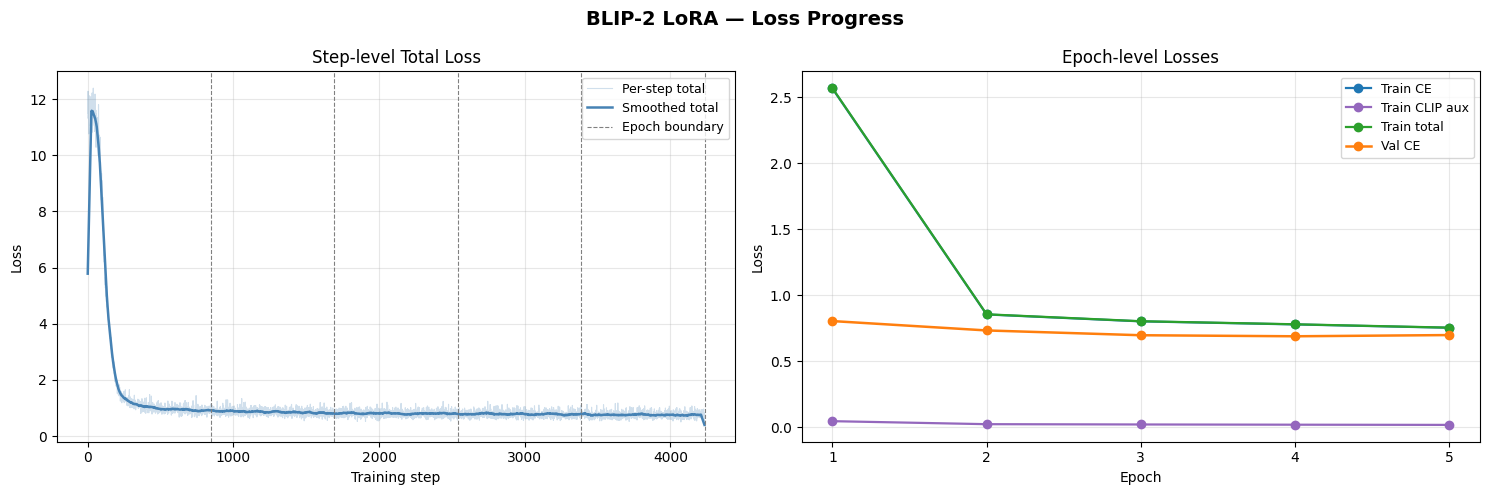

Saved graph: /kaggle/working/blip2_lora_uicd/metric_curves.png


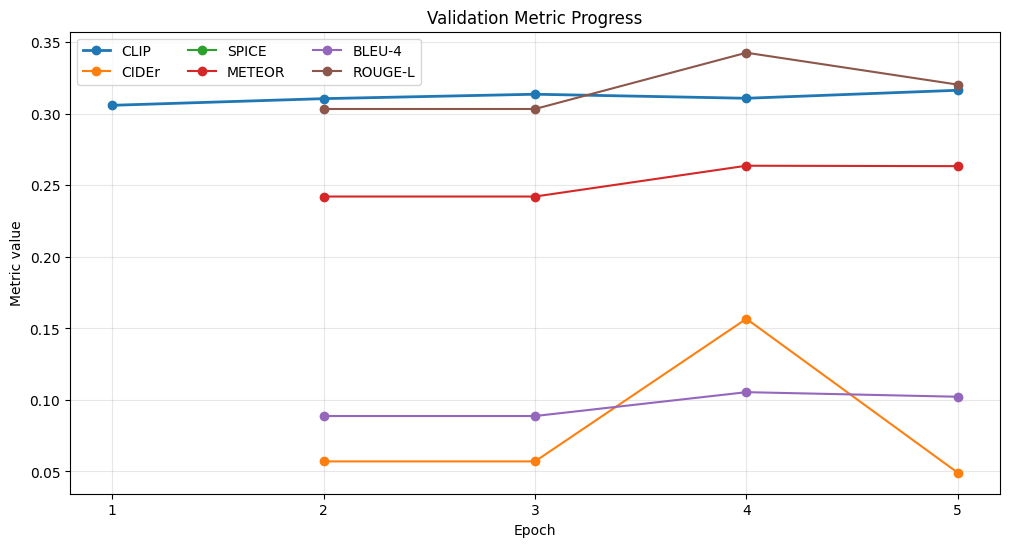

Saved graph: /kaggle/working/blip2_lora_uicd/composite_score_curve.png


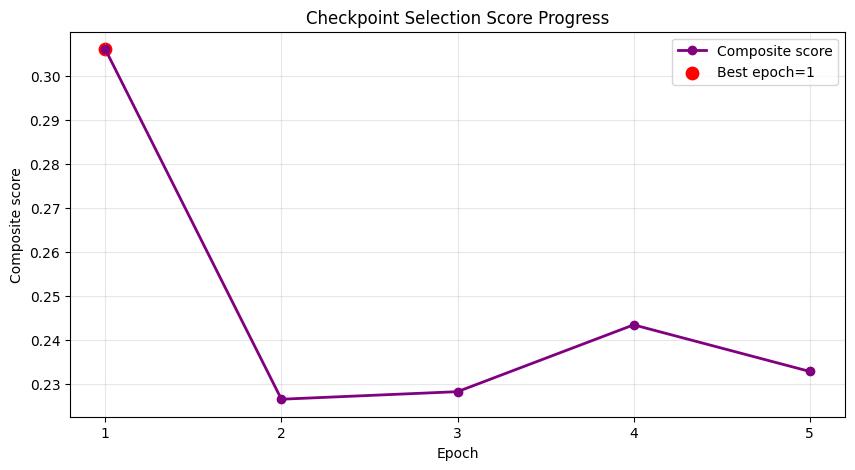

Saved graph: /kaggle/working/blip2_lora_uicd/efficiency_curve.png


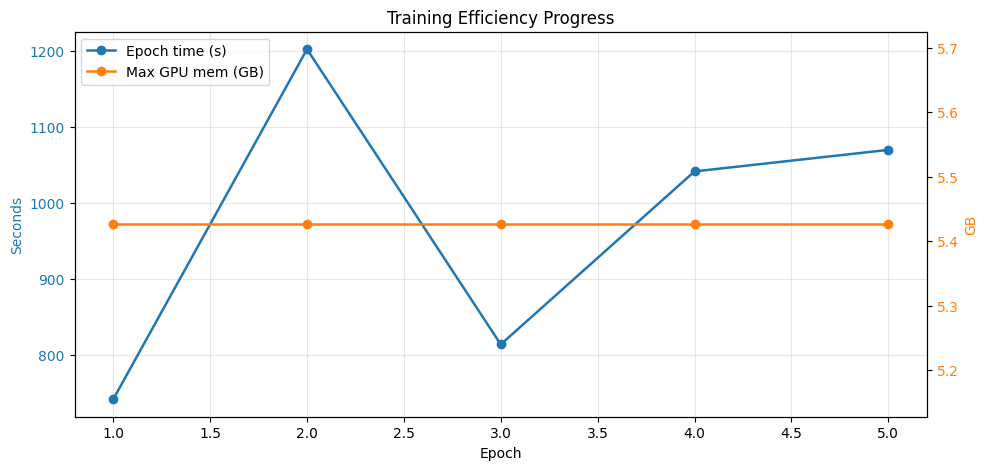

In [12]:
def smooth(values: list, window: int = 50) -> np.ndarray:
    """Simple rolling-mean smoother (same-length output, edge-padded)."""
    arr = np.array(values, dtype=np.float32)
    if len(arr) < window:
        return arr
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode="same")


output_dir = Path(CONFIG["output_dir"])
output_dir.mkdir(parents=True, exist_ok=True)

# Persist epoch history and run metadata for reproducibility.
history_path = output_dir / "epoch_history.json"
with open(history_path, "w", encoding="utf-8") as f:
    json.dump(epoch_history, f, indent=2)
print(f"Saved history: {history_path}")

run_metadata = {
    "seed": CONFIG["seed"],
    "split": CONFIG["split"],
    "epochs": CONFIG["epochs"],
    "batch_size": CONFIG["batch_size"],
    "lr": CONFIG["lr"],
    "clip_aux_weight": CONFIG["clip_aux_weight"],
    "clip_aux_warmup_epochs": CONFIG["clip_aux_warmup_epochs"],
    "clip_aux_every_n_steps": CONFIG["clip_aux_every_n_steps"],
    "metric_weights": CONFIG["metric_weights"],
    "metric_norm": CONFIG["metric_norm"],
}
metadata_path = output_dir / "run_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, indent=2)
print(f"Saved metadata: {metadata_path}")

# ── Graph 1: Loss curves ──────────────────────────────────────────────────────
steps  = [s for s, _ in step_train_losses]
losses = [l for _, l in step_train_losses]
smoothed = smooth(losses)

epochs_x = [r["epoch"] for r in epoch_history]
train_ce = [r["train_ce_loss"] for r in epoch_history]
train_clip_aux = [r["train_clip_aux_loss"] for r in epoch_history]
train_total = [r["train_total_loss"] for r in epoch_history]
val_ce = [r["val_ce_loss"] for r in epoch_history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("BLIP-2 LoRA — Loss Progress", fontsize=14, fontweight="bold")

if steps:
    ax1.plot(steps, losses, color="steelblue", alpha=0.25, linewidth=0.8, label="Per-step total")
    ax1.plot(steps, smoothed, color="steelblue", linewidth=1.8, label="Smoothed total")
    for i, boundary in enumerate(epoch_boundaries):
        ax1.axvline(
            x=boundary,
            color="gray",
            linestyle="--",
            linewidth=0.8,
            label="Epoch boundary" if i == 0 else None,
        )
ax1.set_xlabel("Training step")
ax1.set_ylabel("Loss")
ax1.set_title("Step-level Total Loss")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_x, train_ce, color="tab:blue", marker="o", linewidth=1.6, label="Train CE")
ax2.plot(epochs_x, train_clip_aux, color="tab:purple", marker="o", linewidth=1.6, label="Train CLIP aux")
ax2.plot(epochs_x, train_total, color="tab:green", marker="o", linewidth=1.6, label="Train total")
ax2.plot(epochs_x, val_ce, color="tab:orange", marker="o", linewidth=1.8, label="Val CE")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("Epoch-level Losses")
ax2.set_xticks(epochs_x)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
loss_plot_path = output_dir / "loss_curves.png"
plt.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
print(f"Saved graph: {loss_plot_path}")
plt.show()

# ── Graph 2: Metric curves ────────────────────────────────────────────────────
val_clip = [r["val_clip"] for r in epoch_history]
cider = [r["cider"] for r in epoch_history]
spice = [r["spice"] for r in epoch_history]
meteor = [r["meteor"] for r in epoch_history]
bleu4 = [r["bleu4"] for r in epoch_history]
rouge = [r["rouge"] for r in epoch_history]

plt.figure(figsize=(12, 6))
plt.plot(epochs_x, val_clip, marker="o", linewidth=2.0, label="CLIP")
plt.plot(epochs_x, cider, marker="o", linewidth=1.5, label="CIDEr")
plt.plot(epochs_x, spice, marker="o", linewidth=1.5, label="SPICE")
plt.plot(epochs_x, meteor, marker="o", linewidth=1.5, label="METEOR")
plt.plot(epochs_x, bleu4, marker="o", linewidth=1.5, label="BLEU-4")
plt.plot(epochs_x, rouge, marker="o", linewidth=1.5, label="ROUGE-L")
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("Validation Metric Progress")
plt.xticks(epochs_x)
plt.grid(True, alpha=0.3)
plt.legend(ncol=3)
metric_plot_path = output_dir / "metric_curves.png"
plt.savefig(metric_plot_path, dpi=150, bbox_inches="tight")
print(f"Saved graph: {metric_plot_path}")
plt.show()

# ── Graph 3: Composite score trajectory ───────────────────────────────────────
composite = [r["composite_score"] for r in epoch_history]
best_epoch_idx = int(np.nanargmax(np.array(composite, dtype=np.float32))) if composite else 0
best_epoch = epochs_x[best_epoch_idx] if epochs_x else 0
best_score = composite[best_epoch_idx] if composite else float("nan")

plt.figure(figsize=(10, 5))
plt.plot(epochs_x, composite, color="purple", marker="o", linewidth=2.0, label="Composite score")
if epochs_x:
    plt.scatter([best_epoch], [best_score], color="red", s=80, label=f"Best epoch={best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Composite score")
plt.title("Checkpoint Selection Score Progress")
plt.xticks(epochs_x)
plt.grid(True, alpha=0.3)
plt.legend()
composite_plot_path = output_dir / "composite_score_curve.png"
plt.savefig(composite_plot_path, dpi=150, bbox_inches="tight")
print(f"Saved graph: {composite_plot_path}")
plt.show()

# ── Graph 4: Efficiency trend ─────────────────────────────────────────────────
epoch_seconds = [r["epoch_seconds"] for r in epoch_history]
gpu_mem = [r["max_gpu_mem_gb"] for r in epoch_history]

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(epochs_x, epoch_seconds, color="tab:blue", marker="o", linewidth=1.8, label="Epoch time (s)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Seconds", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_x, gpu_mem, color="tab:orange", marker="o", linewidth=1.8, label="Max GPU mem (GB)")
ax2.set_ylabel("GB", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.title("Training Efficiency Progress")

eff_plot_path = output_dir / "efficiency_curve.png"
plt.savefig(eff_plot_path, dpi=150, bbox_inches="tight")
print(f"Saved graph: {eff_plot_path}")
plt.show()

## 12 · Save Outputs

Saves all artefacts to `/kaggle/working/blip2_lora_uicd/`:

| Path | Contents |
|------|----------|
| `best_checkpoint/` | Best checkpoint by weighted composite score |
| `lora_adapters/` | LoRA adapter weights only (`adapter_model.bin` + config) |
| `processor/` | Tokeniser and image processor |
| `merged_model/` | Full merged model (base + LoRA fused, ~5 GB) |
| `epoch_history.json` | Per-epoch metric and efficiency logs |
| `loss_curves.png` | Step/epoch loss progression |
| `metric_curves.png` | CLIP/CIDEr/SPICE/METEOR/BLEU-4/ROUGE trends |
| `composite_score_curve.png` | Weighted checkpoint score trajectory |
| `efficiency_curve.png` | Epoch runtime and max GPU memory trend |

In [13]:
output_dir = Path(CONFIG["output_dir"])

# ── 1. LoRA adapter weights ───────────────────────────────────────────────────
lora_dir = output_dir / "lora_adapters"
model.save_pretrained(str(lora_dir))
print(f"LoRA adapters saved  → {lora_dir}")

# ── 2. Processor ──────────────────────────────────────────────────────────────
proc_dir = output_dir / "processor"
processor.save_pretrained(str(proc_dir))
print(f"Processor saved      → {proc_dir}")

# ── 3. Merged model (base + LoRA fused) ───────────────────────────────────────
print("Merging LoRA weights into base model (this may take a minute)...")
merged_model = model.merge_and_unload()
merged_dir   = output_dir / "merged_model"
merged_model.save_pretrained(str(merged_dir))
print(f"Merged model saved   → {merged_dir}")

# ── 4. Summary ────────────────────────────────────────────────────────────────
print("\n── Saved files ──────────────────────────────────────────")
for p in sorted(output_dir.rglob("*")):
    if p.is_file():
        size_mb = p.stat().st_size / 1024**2
        print(f"  {p.relative_to(output_dir)}  ({size_mb:.1f} MB)")
print("─────────────────────────────────────────────────────────")


LoRA adapters saved  → /kaggle/working/blip2_lora_uicd/lora_adapters
Processor saved      → /kaggle/working/blip2_lora_uicd/processor
Merging LoRA weights into base model (this may take a minute)...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Merged model saved   → /kaggle/working/blip2_lora_uicd/merged_model

── Saved files ──────────────────────────────────────────
  best_checkpoint/README.md  (0.0 MB)
  best_checkpoint/adapter_config.json  (0.0 MB)
  best_checkpoint/adapter_model.safetensors  (20.0 MB)
  best_checkpoint/processor_config.json  (0.0 MB)
  best_checkpoint/tokenizer.json  (3.4 MB)
  best_checkpoint/tokenizer_config.json  (0.0 MB)
  composite_score_curve.png  (0.1 MB)
  efficiency_curve.png  (0.1 MB)
  epoch_history.json  (0.0 MB)
  lora_adapters/README.md  (0.0 MB)
  lora_adapters/adapter_config.json  (0.0 MB)
  lora_adapters/adapter_model.safetensors  (20.0 MB)
  loss_curves.png  (0.1 MB)
  merged_model/config.json  (0.0 MB)
  merged_model/generation_config.json  (0.0 MB)
  merged_model/model.safetensors  (7343.3 MB)
  metric_curves.png  (0.1 MB)
  processor/processor_config.json  (0.0 MB)
  processor/tokenizer.json  (3.4 MB)
  processor/tokenizer_config.json  (0.0 MB)
  run_metadata.json  (0.0 MB)
────────

## 13 · Package Outputs as ZIP

Creates `blip2_lora_uicd.zip` in `/kaggle/working/` containing all saved artefacts for easy download.

In [ ]:
import zipfile

output_dir = Path(CONFIG["output_dir"])
zip_path   = output_dir.parent / f"{output_dir.name}.zip"

print(f"Creating archive: {zip_path}")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for file in sorted(output_dir.rglob("*")):
        if file.is_file():
            arcname = file.relative_to(output_dir.parent)
            zf.write(file, arcname)

zip_size_mb = zip_path.stat().st_size / 1024**2
print(f"Done. Archive size: {zip_size_mb:.1f} MB  →  {zip_path}")

Creating archive: /kaggle/working/blip2_lora_uicd.zip
